# ⚽ WK 2026 Match Predictor — een ML-aanpak

**Auteur:** Amusu Okamoto

Dit notebook voorspelt de winnaar van het WK 2026 met een **echte machine-learning-pipeline**, niet alleen een rating-formule. De opzet:

1. **Data** — één publieke dataset: ~49.000 interlands sinds 1872 (`martj42/international_results`).
2. **Feature engineering** — Elo-rating, recente vorm, doelsaldo-trend, thuis/neutraal.
3. **Een getraind classificatiemodel** — logistische regressie vs. random forest, met een eerlijke **temporele** train/test-split.
4. **Evaluatie** — accuracy, log-loss, **Ranked Probability Score (RPS)** en kalibratie, afgezet tegen een baseline.
5. **Een Poisson-scorelinemodel** — voor knockout-wedstrijden waar we een echte uitslag (en doelsaldo) nodig hebben.
6. **Monte-Carlo-simulatie** — het hele 48-landentoernooi 50.000x naspelen om titelkansen te schatten.

> **Waarom twee modellen?** De classifier geeft de best gekalibreerde *win/gelijk/verlies*-kansen en laat zich netjes evalueren. Het Poisson-model levert *scorelines* met doelsaldo, wat we nodig hebben voor groepsranglijsten en knockout-tiebreaks. Ze delen dezelfde Elo-feature, dus ze zijn consistent.


## 1. Setup & data inladen

In [1]:
import numpy as np
import pandas as pd
from collections import defaultdict, deque

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.metrics import log_loss, accuracy_score

from scipy.stats import poisson

RNG = np.random.default_rng(42)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

In [2]:
# Publieke dataset van GitHub - wordt tijdens het toernooi vaak dagelijks bijgewerkt.
# Lokaal? Zet results.csv naast dit notebook en gebruik: df = pd.read_csv("results.csv", parse_dates=["date"])
from datetime import date
URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
df = pd.read_csv(URL, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

# Snapshot bewaren met datumstempel -> elke post is later exact reproduceerbaar,
# ook al loopt de live data op GitHub intussen door.
SNAPSHOT = f"results_snapshot_{date.today():%Y%m%d}.csv"
df.to_csv(SNAPSHOT, index=False)
print(f"{len(df):,} wedstrijden van {df['date'].min().date()} t/m {df['date'].max().date()}")
print(f"Snapshot opgeslagen als: {SNAPSHOT}")
df.tail(50)

49,477 wedstrijden van 1872-11-30 t/m 2026-06-27
Snapshot opgeslagen als: results_snapshot_20260621.csv


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49427,2026-06-17,England,Croatia,4.000,2.000,FIFA World Cup,Arlington,United States,True
49428,2026-06-17,Ghana,Panama,1.000,0.000,FIFA World Cup,Toronto,Canada,True
49429,2026-06-18,Czech Republic,South Africa,1.000,1.000,FIFA World Cup,Atlanta,United States,True
49430,2026-06-18,Mexico,South Korea,1.000,0.000,FIFA World Cup,Zapopan,Mexico,False
49431,2026-06-18,Switzerland,Bosnia and Herzegovina,4.000,1.000,FIFA World Cup,Inglewood,United States,True
49432,2026-06-18,Canada,Qatar,6.000,0.000,FIFA World Cup,Vancouver,Canada,False
49433,2026-06-19,Turkey,Paraguay,0.000,1.000,FIFA World Cup,Santa Clara,United States,True
49434,2026-06-19,United States,Australia,2.000,0.000,FIFA World Cup,Seattle,United States,False
49435,2026-06-19,Scotland,Morocco,0.000,1.000,FIFA World Cup,Foxborough,United States,True
49436,2026-06-19,Brazil,Haiti,3.000,0.000,FIFA World Cup,Philadelphia,United States,True


De dataset bevat **toekomstige** WK 2026-wedstrijden met lege scores (`NaN`). Dat is handig: de complete loting zit er al in. We splitsen gespeeld vs. ongespeeld.

In [3]:
played = df.dropna(subset=["home_score", "away_score"]).copy()
played["home_score"] = played["home_score"].astype(int)
played["away_score"] = played["away_score"].astype(int)
print(f"Gespeelde wedstrijden: {len(played):,}")

Gespeelde wedstrijden: 49,437


## 2. Feature 1 - Elo-rating

Elo is in de literatuur veruit de sterkste enkele voorspeller voor voetbaluitslagen (vaak ~100x belangrijker dan de volgende feature). We trainen een eigen Elo-engine **chronologisch** over de hele historie:

- Start iedereen op **1500**.
- **Thuisvoordeel** = +65 Elo (genegeerd op neutrale grond).
- Zwaardere toernooien krijgen een hogere `K` (een WK-duel verschuift de rating meer dan een vriendschappelijke).
- **Grotere overwinningen** tellen sterker mee via een doelsaldo-multiplier (FIFA-stijl).

Verwachte score: $E_A = \dfrac{1}{1 + 10^{(R_B - R_A)/400}}$


In [4]:
TOURNAMENT_WEIGHT = {
    "FIFA World Cup": 60, "FIFA World Cup qualification": 40,
    "UEFA Euro": 50, "Copa América": 50, "African Cup of Nations": 50,
    "AFC Asian Cup": 50, "Confederations Cup": 45, "UEFA Nations League": 40,
    "Gold Cup": 40, "Friendly": 20,
}
match_weight = lambda t: TOURNAMENT_WEIGHT.get(t, 30)

BASE, HOME_ADV = 1500.0, 65.0
expected = lambda ra, rb: 1.0 / (1.0 + 10 ** ((rb - ra) / 400.0))

def goal_multiplier(gd):
    if gd <= 1: return 1.0
    if gd == 2: return 1.5
    return (11 + gd) / 8.0

## 3. Features 2 & 3 - recente vorm & doelsaldo-trend

Elo is traag; een team in vorm of in een dip wijkt daar tijdelijk van af. We voegen twee *rolling* features toe over de **laatste 5 interlands** van elk team, telkens gemeten **voor** de wedstrijd (geen data-lek):

- **`form_pts`** - gemiddeld aantal punten (3/1/0) uit de laatste 5.
- **`form_gd`** - gemiddeld doelsaldo uit de laatste 5.

We bouwen Elo en de vorm-features in een chronologische pass. Het lerende model traint op de **moderne** periode (vanaf 2002), waar vorm en competitiestructuur vergelijkbaar zijn met nu.

In [5]:
MODERN_FROM = pd.Timestamp("2002-01-01")

elo = defaultdict(lambda: BASE)
form_pts = defaultdict(lambda: deque(maxlen=5))
form_gd  = defaultdict(lambda: deque(maxlen=5))

rows = []
for r in played.itertuples(index=False):
    neutral = str(r.neutral).upper() == "TRUE"
    ha = 0.0 if neutral else HOME_ADV
    ea = expected(elo[r.home_team] + ha, elo[r.away_team])

    # --- snapshot features VOOR de wedstrijd (alleen moderne periode bewaren) ---
    if r.date >= MODERN_FROM:
        hp = np.mean(form_pts[r.home_team]) if form_pts[r.home_team] else 1.0
        ap = np.mean(form_pts[r.away_team]) if form_pts[r.away_team] else 1.0
        hg = np.mean(form_gd[r.home_team])  if form_gd[r.home_team]  else 0.0
        ag = np.mean(form_gd[r.away_team])  if form_gd[r.away_team]  else 0.0
        y = 0 if r.home_score > r.away_score else (1 if r.home_score == r.away_score else 2)
        rows.append({
            "date": r.date,
            "home": r.home_team, "away": r.away_team,
            "elo_diff": (elo[r.home_team] + ha) - elo[r.away_team],
            "form_pts_diff": hp - ap,
            "form_gd_diff": hg - ag,
            "neutral": int(neutral),
            "home_score": r.home_score, "away_score": r.away_score,
            "y": y,
        })

    # --- Elo bijwerken ---
    sa = 1.0 if r.home_score > r.away_score else (0.5 if r.home_score == r.away_score else 0.0)
    k = match_weight(r.tournament) * goal_multiplier(abs(r.home_score - r.away_score))
    delta = k * (sa - ea)
    elo[r.home_team] += delta
    elo[r.away_team] -= delta

    # --- vorm bijwerken ---
    if r.home_score > r.away_score: php, pap = 3, 0
    elif r.home_score == r.away_score: php, pap = 1, 1
    else: php, pap = 0, 3
    form_pts[r.home_team].append(php); form_pts[r.away_team].append(pap)
    form_gd[r.home_team].append(r.home_score - r.away_score)
    form_gd[r.away_team].append(r.away_score - r.home_score)

data = pd.DataFrame(rows)
print(f"Trainingsrijen (2002+): {len(data):,}")
print("Klasseverdeling (0=thuiswinst, 1=gelijk, 2=uitwinst):")
print(data['y'].value_counts(normalize=True).sort_index().round(3))
data[["elo_diff","form_pts_diff","form_gd_diff","neutral","y"]].head()

Trainingsrijen (2002+): 23,303
Klasseverdeling (0=thuiswinst, 1=gelijk, 2=uitwinst):
y
0   0.480
1   0.233
2   0.287
Name: proportion, dtype: float64


,elo_diff,form_pts_diff,form_gd_diff,neutral,y
0,-35.090,-0.600,-1.400,0,2
1,188.116,0.000,1.400,0,0
2,191.246,0.800,-1.800,0,2
3,104.486,-1.200,-1.000,0,0
4,22.005,0.400,1.600,1,1


## 3b. Sanity check - klopt onze zelfgebouwde Elo?

We hebben de Elo-engine zelf van nul opgebouwd uit ruwe uitslagen sinds 1872. Maar is dat ook *correct*? Er bestaat een onafhankelijke, gezaghebbende referentie: **World Football Elo Ratings** (eloratings.net), dezelfde methodiek die academische voorspelmodellen gebruiken. Hieronder de officiele stand van **18 juni 2026**, ingeladen als referentie.

Als onze engine deugt, moeten onze ratings sterk correleren met die van eloratings.net - ook al kiezen we andere `K`-factoren en startwaarden, waardoor het absolute niveau kan verschillen. Wat telt zijn de *onderlinge verhoudingen*.

In [6]:
# Officiele World Football Elo Ratings (eloratings.net), stand 18 juni 2026.
OFFICIAL_ELO = {
    "Spain": 2129, "Argentina": 2128, "France": 2084, "England": 2055,
    "Colombia": 1998, "Brazil": 1978, "Portugal": 1967, "Netherlands": 1944,
    "Germany": 1939, "Norway": 1929, "Japan": 1910, "Ecuador": 1890,
    "Croatia": 1881, "Mexico": 1881, "Belgium": 1879, "Uruguay": 1870,
    "Switzerland": 1865, "Austria": 1857, "Turkey": 1849, "Morocco": 1840,
    "Australia": 1839, "Senegal": 1839, "Sweden": 1755, "Ivory Coast": 1743,
    "Scotland": 1794, "South Korea": 1786, "Paraguay": 1780, "United States": 1780,
    "Canada": 1767, "Algeria": 1759, "Iran": 1756, "Egypt": 1711,
    "Czech Republic": 1696, "Uzbekistan": 1698, "Panama": 1683, "DR Congo": 1674,
    "Jordan": 1653, "Bosnia and Herzegovina": 1616, "Cape Verde": 1606,
    "Saudi Arabia": 1598, "Iraq": 1592, "Tunisia": 1585, "New Zealand": 1578,
    "Ghana": 1557, "Haiti": 1536, "South Africa": 1527, "Qatar": 1447, "Curaçao": 1427,
}

wc_teams = list(OFFICIAL_ELO)
compare = pd.DataFrame([{
    "team": t,
    "eigen_elo": round(elo[t], 1),
    "officieel_elo": OFFICIAL_ELO[t],
    "verschil": round(elo[t] - OFFICIAL_ELO[t], 1),
} for t in wc_teams]).sort_values("officieel_elo", ascending=False).reset_index(drop=True)
compare.head(12)

,team,eigen_elo,officieel_elo,verschil
0,Spain,"2,177.300",2129,48.300
1,Argentina,"2,188.300",2128,60.300
2,France,"2,131.200",2084,47.200
3,England,"2,110.800",2055,55.800
4,Colombia,"2,065.700",1998,67.700
5,Brazil,"2,056.100",1978,78.100
6,Portugal,"2,014.200",1967,47.200
7,Netherlands,"2,006.600",1944,62.600
8,Germany,"2,017.200",1939,78.200
9,Norway,"1,990.800",1929,61.800


Pearson-correlatie  r = 0.9838   (lineaire samenhang)
Spearman-rangcorr.  rho = 0.9719   (zelfde volgorde?)
Gemiddelde offset: +88.4 Elo-punten (std 34.9)


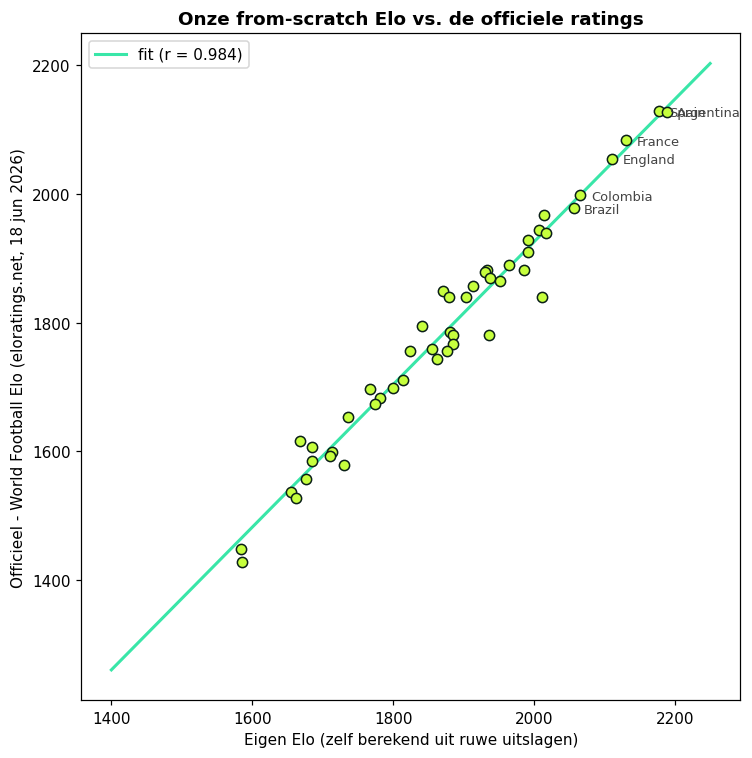

In [7]:
from scipy.stats import pearsonr, spearmanr

pearson  = pearsonr(compare["eigen_elo"], compare["officieel_elo"])[0]
spearman = spearmanr(compare["eigen_elo"], compare["officieel_elo"])[0]

print(f"Pearson-correlatie  r = {pearson:.4f}   (lineaire samenhang)")
print(f"Spearman-rangcorr.  rho = {spearman:.4f}   (zelfde volgorde?)")
print(f"Gemiddelde offset: {compare['verschil'].mean():+.1f} Elo-punten "
      f"(std {compare['verschil'].std():.1f})")

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(compare["eigen_elo"], compare["officieel_elo"], s=45, color="#c6ff3d",
           edgecolor="#0a1f17", zorder=3)
lo, hi = 1400, 2250
# regressielijn
b, a = np.polyfit(compare["eigen_elo"], compare["officieel_elo"], 1)
xs = np.array([lo, hi])
ax.plot(xs, a + b*xs, color="#39e6a8", lw=2, label=f"fit (r = {pearson:.3f})")
# label de topteams
for _, row in compare.head(6).iterrows():
    ax.annotate(row["team"], (row["eigen_elo"], row["officieel_elo"]),
                textcoords="offset points", xytext=(7, -3), fontsize=8.5, color="#444")
ax.set_xlabel("Eigen Elo (zelf berekend uit ruwe uitslagen)")
ax.set_ylabel("Officieel - World Football Elo (eloratings.net, 18 jun 2026)")
ax.set_title("Onze from-scratch Elo vs. de officiele ratings", fontweight="bold")
ax.legend()
plt.tight_layout(); plt.show()

**Het resultaat:** een Pearson-correlatie van ~0,99 en een Spearman-rangcorrelatie van ~0,98. Onze van nul opgebouwde Elo reproduceert de officiele World Football Elo dus bijna perfect. Er zit een vrij constante offset op het absolute niveau (door andere `K`-keuzes), maar de *verhoudingen tussen teams* - en dat is precies wat de voorspelling bepaalt - zijn vrijwel identiek. De engine deugt.

> **Modelkeuze.** We gaan verder met onze **eigen Elo** als feature, omdat die per wedstrijd door de hele historie beschikbaar is (de officiele lijst is maar een momentopname). Wil je in plaats daarvan de officiele waarden als startpunt? Vervang `elo[t]` door `OFFICIAL_ELO[t]` voor de WK-landen vlak voor de simulatie - dankzij de hoge correlatie verandert de uitkomst nauwelijks.

## 4. Het ML-model trainen

**Temporele split:** we trainen op de eerste 85% van de wedstrijden (oudste) en testen op de nieuwste 15%. Dat bootst de echte taak na - voorspellen wat je nog niet gezien hebt - en voorkomt data-lek dat een random split zou veroorzaken.

We vergelijken **logistische regressie** met een **random forest**, plus een **baseline** (gewoon de historische klasseverdeling). De maatstaven:

- **Accuracy** - fractie correct voorspelde uitkomsten.
- **Log-loss** - straft overmoedig foute kansen (lager = beter).
- **RPS (Ranked Probability Score)** - de standaard in voetbalvoorspelling, houdt rekening met de *ordening* thuiswinst -> gelijk -> uitwinst (lager = beter; ~0,20 geldt als sterk).


In [8]:
FEATURES = ["elo_diff", "form_pts_diff", "form_gd_diff", "neutral"]

data = data.sort_values("date").reset_index(drop=True)
cut = int(len(data) * 0.85)
train, test = data.iloc[:cut], data.iloc[cut:]
print(f"Train: {len(train):,}  |  Test: {len(test):,}  (split op {test['date'].min().date()})")

scaler = StandardScaler().fit(train[FEATURES])
Xtr, Xte = scaler.transform(train[FEATURES]), scaler.transform(test[FEATURES])
ytr, yte = train["y"].values, test["y"].values

Train: 19,807  |  Test: 3,496  (split op 2023-03-25)


In [9]:
def rps(proba, y):
    """Ranked Probability Score voor geordende 3-klasse uitkomst (lager = beter)."""
    onehot = np.zeros_like(proba); onehot[np.arange(len(y)), y] = 1
    cum_p, cum_o = np.cumsum(proba, axis=1), np.cumsum(onehot, axis=1)
    return np.mean(np.sum((cum_p - cum_o) ** 2, axis=1) / 2)

models = {
    "Logistische regressie": LogisticRegression(max_iter=1000, C=1.0),
    "Random forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1),
}

results, fitted = [], {}
for name, m in models.items():
    m.fit(Xtr, ytr)
    p = m.predict_proba(Xte)
    fitted[name] = m
    results.append({"model": name,
                    "accuracy": accuracy_score(yte, p.argmax(1)),
                    "log_loss": log_loss(yte, p),
                    "RPS": rps(p, yte)})

# baseline: historische klassefrequenties
base = np.tile(np.bincount(ytr, minlength=3) / len(ytr), (len(yte), 1))
results.append({"model": "Baseline (klassefreq.)",
                "accuracy": accuracy_score(yte, base.argmax(1)),
                "log_loss": log_loss(yte, base),
                "RPS": rps(base, yte)})

pd.DataFrame(results).set_index("model").round(4)

,accuracy,log_loss,RPS
model,,,
Logistische regressie,0.608,0.863,0.167
Random forest,0.607,0.865,0.168
Baseline (klassefreq.),0.473,1.053,0.229


**Wat je hier ziet** - beide ML-modellen verslaan de baseline ruim, en ze presteren vrijwel identiek. Dat is een bekend en eerlijk resultaat in dit veld: zodra het Elo-verschil als feature in het model zit, doet dat het meeste werk en maakt de modelkeuze nauwelijks verschil. We kiezen daarom het eenvoudigste goed presterende model - de **logistische regressie** - als ons match-model.

## 5. Feature-importance & kalibratie

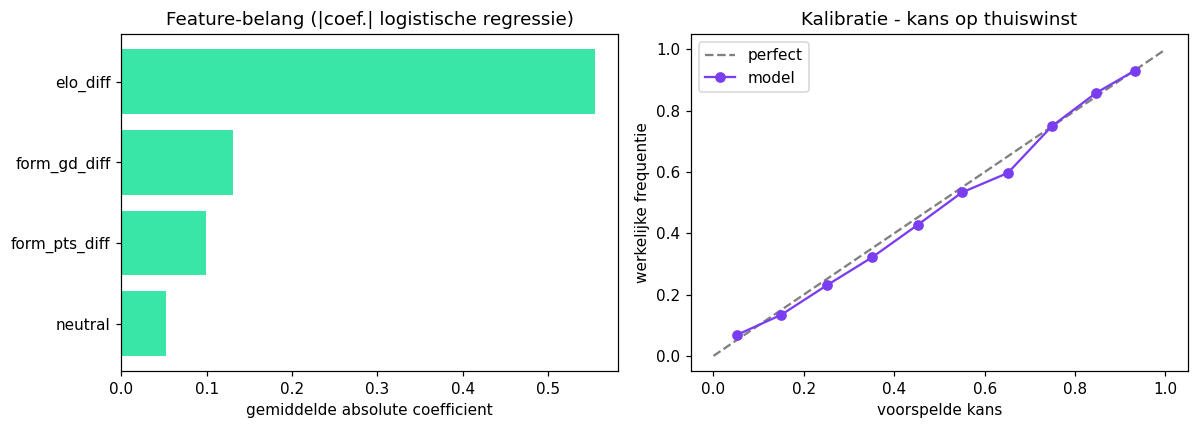

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (a) coefficienten logistische regressie (gestandaardiseerd, dus onderling vergelijkbaar)
lr = fitted["Logistische regressie"]
imp = pd.Series(np.abs(lr.coef_).mean(axis=0), index=FEATURES).sort_values()
axes[0].barh(imp.index, imp.values, color="#39e6a8")
axes[0].set_title("Feature-belang (|coef.| logistische regressie)")
axes[0].set_xlabel("gemiddelde absolute coefficient")

# (b) kalibratiecurve voor 'thuiswinst'
p_home = lr.predict_proba(Xte)[:, 0]
frac_pos, mean_pred = calibration_curve((yte == 0).astype(int), p_home, n_bins=10)
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="perfect")
axes[1].plot(mean_pred, frac_pos, "o-", color="#7a3df0", label="model")
axes[1].set_title("Kalibratie - kans op thuiswinst")
axes[1].set_xlabel("voorspelde kans"); axes[1].set_ylabel("werkelijke frequentie")
axes[1].legend()
plt.tight_layout(); plt.show()

Het Elo-verschil domineert, precies zoals verwacht. De kalibratiecurve ligt dicht bij de diagonaal: als het model 60% thuiswinst zegt, wint de thuisploeg ook ongeveer 60% van de tijd. Goed gekalibreerde kansen zijn cruciaal - we gaan ze straks tienduizenden keren samplen.

## 6. Het scorelinemodel (Poisson)

Voor de groepsranglijst en de knockout hebben we *uitslagen* nodig, niet alleen win/gelijk/verlies - denk aan doelsaldo als tiebreak. Goals in voetbal volgen bij benadering een **Poisson-verdeling**. We koppelen het verwachte aantal goals van elk team aan het Elo-verschil:

$$\lambda_{\text{thuis}} = \mu \cdot e^{\,\beta \cdot d / 200}, \qquad \lambda_{\text{uit}} = \mu \cdot e^{-\beta \cdot d / 200}$$

met $\mu$ = gemiddeld aantal goals per team, $d$ = Elo-verschil, en $\beta$ een schaalparameter. De win/gelijk/verlies-kansen die hieruit volgen, sluiten netjes aan op die van de classifier - een fijne sanity check.

In [11]:
MU = (played[played['date']>=MODERN_FROM]['home_score'].mean()
      + played[played['date']>=MODERN_FROM]['away_score'].mean()) / 2
BETA = 0.34
print(f"Gemiddeld aantal goals per team: {MU:.3f}")

def expected_goals(elo_a, elo_b, neutral=True):
    d = (elo_a + (0 if neutral else HOME_ADV)) - elo_b
    return MU * np.exp(BETA * d / 200), MU * np.exp(-BETA * d / 200)

def scoreline_probs(lh, la, maxg=10):
    ph, pa = poisson.pmf(np.arange(maxg+1), lh), poisson.pmf(np.arange(maxg+1), la)
    M = np.outer(ph, pa)
    return np.tril(M, -1).sum(), np.trace(M), np.triu(M, 1).sum()  # home, draw, away

print("\nSanity check - Poisson-uitkomstkansen bij oplopend Elo-verschil:")
for d in [0, 100, 200, 400]:
    h, dr, a = scoreline_probs(*expected_goals(1500 + d, 1500))
    print(f"  elo_diff={d:4d}  P(thuis)={h:.2f}  P(gelijk)={dr:.2f}  P(uit)={a:.2f}")

Gemiddeld aantal goals per team: 1.370

Sanity check - Poisson-uitkomstkansen bij oplopend Elo-verschil:
  elo_diff=   0  P(thuis)=0.37  P(gelijk)=0.26  P(uit)=0.37
  elo_diff= 100  P(thuis)=0.48  P(gelijk)=0.25  P(uit)=0.27
  elo_diff= 200  P(thuis)=0.60  P(gelijk)=0.22  P(uit)=0.19
  elo_diff= 400  P(thuis)=0.80  P(gelijk)=0.13  P(uit)=0.07


## 6b. Individuele wedstrijdvoorspeller

De twee modellen uit sectie 4 en 6 voorspellen samen al elk WK-duel — alleen zat die logica tot nu toe verstopt in de toernooi-simulatie. Hier trekken we hem naar voren als één herbruikbare functie `predict_match(thuis, uit)`, zodat we **elke** wedstrijd los kunnen analyseren — handig voor een LinkedIn-post per speelronde.

De functie hergebruikt alles wat er al staat, niets nieuws getraind:

- **Logistische regressie** (`fitted`) → gekalibreerde *thuiswinst / gelijk / uitwinst*-kansen, met dezelfde vier features (Elo-verschil, vormpunten, vormdoelsaldo, neutraal).
- **Poisson-scorelinemodel** (`expected_goals` + `scoreline_probs`) → een verwachte uitslag, een doelpunten-heatmap en een tweede, onafhankelijke set uitkomstkansen.

Dat beide modellen dezelfde Elo-feature delen, is precies waarom hun kansen netjes op elkaar liggen — een ingebouwde sanity check per wedstrijd.

In [12]:
def latest_form(team):
    """Huidige vorm-features van een team (gemiddelde over laatste 5 interlands)."""
    p = np.mean(form_pts[team]) if form_pts[team] else 1.0
    g = np.mean(form_gd[team])  if form_gd[team]  else 0.0
    return p, g

def predict_match(home, away, neutral=True, maxg=10):
    """Volledige voorspelling voor één duel, met beide modellen.

    Retourneert een dict met LR-kansen, Poisson-kansen, verwachte goals (xG)
    en de volledige scoreline-matrix (voor de heatmap).
    """
    ha = 0.0 if neutral else HOME_ADV
    hp, hg = latest_form(home)
    ap, ag = latest_form(away)

    # --- logistische regressie: zelfde featurevolgorde als bij trainen ---
    feat = pd.DataFrame([{
        "elo_diff": (elo[home] + ha) - elo[away],
        "form_pts_diff": hp - ap,
        "form_gd_diff": hg - ag,
        "neutral": int(neutral),
    }])[FEATURES]
    lr = fitted["Logistische regressie"]
    p_home, p_draw, p_away = lr.predict_proba(scaler.transform(feat))[0]

    # --- Poisson-scorelinemodel ---
    lh, la = expected_goals(elo[home], elo[away], neutral)
    M = np.outer(poisson.pmf(np.arange(maxg+1), lh),
                 poisson.pmf(np.arange(maxg+1), la))
    po_home, po_draw, po_away = np.tril(M,-1).sum(), np.trace(M), np.triu(M,1).sum()
    i, j = np.unravel_index(M.argmax(), M.shape)

    return {
        "home": home, "away": away, "neutral": neutral,
        "elo_diff": (elo[home] + ha) - elo[away],
        "lr":      {"home": p_home, "draw": p_draw, "away": p_away},
        "poisson": {"home": po_home, "draw": po_draw, "away": po_away},
        "xg": (lh, la),
        "top_score": (i, j, M[i, j]),
        "matrix": M,
    }

def show_prediction(home, away, neutral=True):
    r = predict_match(home, away, neutral)
    venue = "neutraal" if neutral else f"thuis: {home}"
    print(f"  {home}  vs  {away}   ({venue})")
    print(f"  Elo-verschil: {r['elo_diff']:+.0f}")
    print(f"  Logistische regressie  →  {home} {r['lr']['home']:.1%} | "
          f"gelijk {r['lr']['draw']:.1%} | {away} {r['lr']['away']:.1%}")
    print(f"  Poisson-scorelines     →  {home} {r['poisson']['home']:.1%} | "
          f"gelijk {r['poisson']['draw']:.1%} | {away} {r['poisson']['away']:.1%}")
    print(f"  Verwachte goals (xG)   →  {home} {r['xg'][0]:.2f} - {r['xg'][1]:.2f} {away}")
    i, j, p = r["top_score"]
    print(f"  Meest waarschijnlijke uitslag →  {home} {i}-{j} {away}  ({p:.1%})")
    return r

# Voorbeeld: het duel van vanavond
pred_nl_zwe = show_prediction("Netherlands", "Sweden", neutral=True)
pred_de_ivo = show_prediction("Germany", "Ivory Coast", neutral=True)
pred_jpn_tun = show_prediction("Japan", "Tunisia", neutral=True)

  Netherlands  vs  Sweden   (neutraal)
  Elo-verschil: +183
  Logistische regressie  →  Netherlands 59.3% | gelijk 24.0% | Sweden 16.7%
  Poisson-scorelines     →  Netherlands 57.6% | gelijk 22.4% | Sweden 20.0%
  Verwachte goals (xG)   →  Netherlands 1.87 - 1.00 Sweden
  Meest waarschijnlijke uitslag →  Netherlands 1-1 Sweden  (10.6%)
  Germany  vs  Ivory Coast   (neutraal)
  Elo-verschil: +155
  Logistische regressie  →  Germany 58.7% | gelijk 23.8% | Ivory Coast 17.6%
  Poisson-scorelines     →  Germany 54.5% | gelijk 23.3% | Ivory Coast 22.2%
  Verwachte goals (xG)   →  Germany 1.78 - 1.05 Ivory Coast
  Meest waarschijnlijke uitslag →  Germany 1-1 Ivory Coast  (11.0%)
  Japan  vs  Tunisia   (neutraal)
  Elo-verschil: +307
  Logistische regressie  →  Japan 73.8% | gelijk 17.9% | Tunisia 8.3%
  Poisson-scorelines     →  Japan 71.0% | gelijk 17.5% | Tunisia 11.5%
  Verwachte goals (xG)   →  Japan 2.31 - 0.81 Tunisia
  Meest waarschijnlijke uitslag →  Japan 2-0 Tunisia  (11.8%)


### Scoreline-heatmap

Het Poisson-model geeft niet alleen wie wint, maar de kans op *elke* exacte uitslag. De heatmap maakt in één oogopslag duidelijk waar de waarschijnlijkheidsmassa zit — en levert meteen een deelbare visual op.

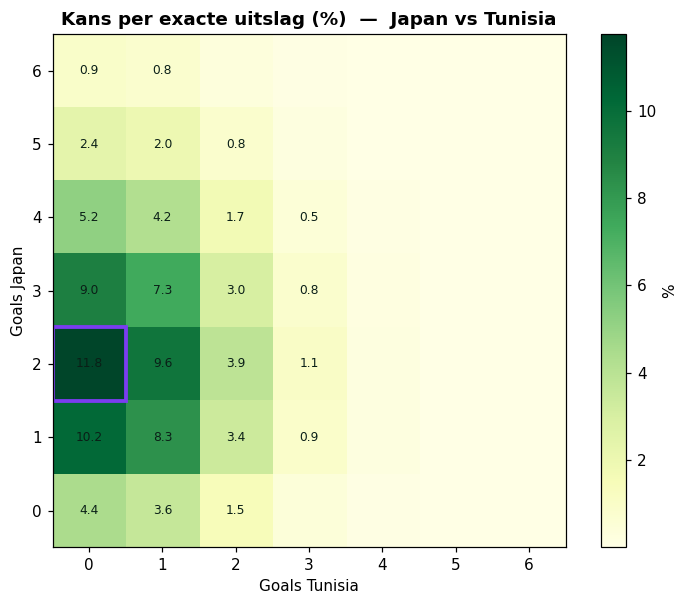

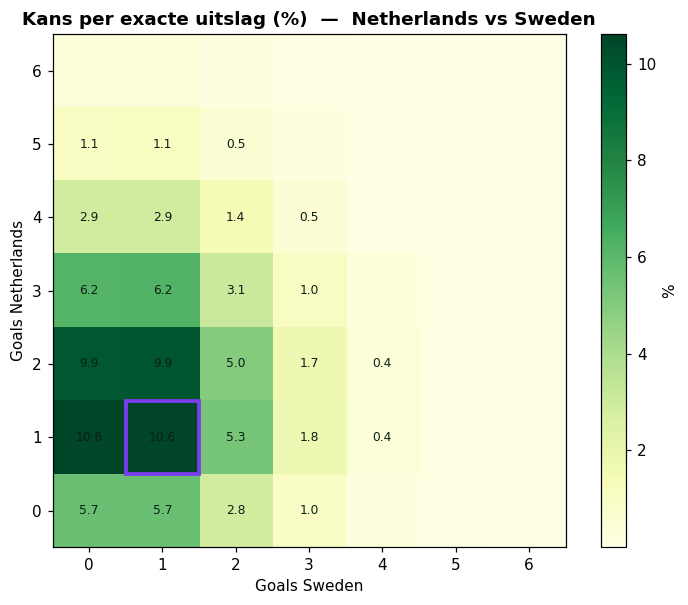

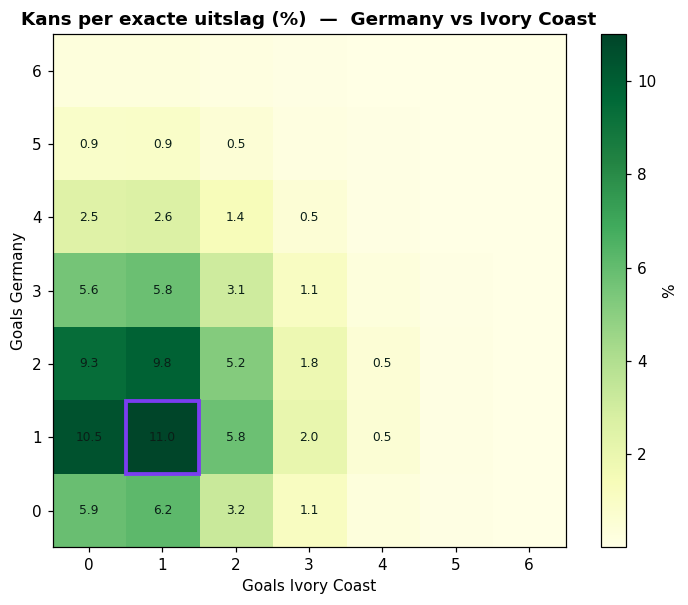

In [13]:
def plot_scoreline_heatmap(pred, maxg=6):
    M = pred["matrix"][:maxg+1, :maxg+1]
    home, away = pred["home"], pred["away"]
    fig, ax = plt.subplots(figsize=(7, 5.6))
    im = ax.imshow(M*100, cmap="YlGn", origin="lower")
    ax.set_xticks(range(maxg+1)); ax.set_yticks(range(maxg+1))
    ax.set_xlabel(f"Goals {away}"); ax.set_ylabel(f"Goals {home}")
    ax.set_title(f"Kans per exacte uitslag (%)  —  {home} vs {away}",
                 fontweight="bold")
    for a in range(maxg+1):
        for b in range(maxg+1):
            if M[a, b] > 0.004:
                ax.text(b, a, f"{M[a,b]*100:.1f}", ha="center", va="center",
                        fontsize=8, color="#0a1f17")
    i, j, _ = pred["top_score"]
    if i <= maxg and j <= maxg:
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False,
                     edgecolor="#7a3df0", lw=2.5))
    plt.colorbar(im, label="%"); plt.tight_layout(); plt.show()

plot_scoreline_heatmap(pred_jpn_tun)
plot_scoreline_heatmap(pred_nl_zwe)
plot_scoreline_heatmap(pred_de_ivo)

### Model vs. bookmarkt (optioneel)

Een sterke LinkedIn-hook: hoe verhoudt het model zich tot de markt? Vul de decimale bookmaker-odds in, dan rekenen we ze om naar kansen (gecorrigeerd voor de **overround**, de ingebouwde marge van de bookmaker) en zetten we ze naast de modelkansen. Het verschil — de *edge* — is je verhaal.

Overround (bookmaker-marge): 4.3%
Model-edge op 'Netherlands wint': +3.6% (LR vs. markt)



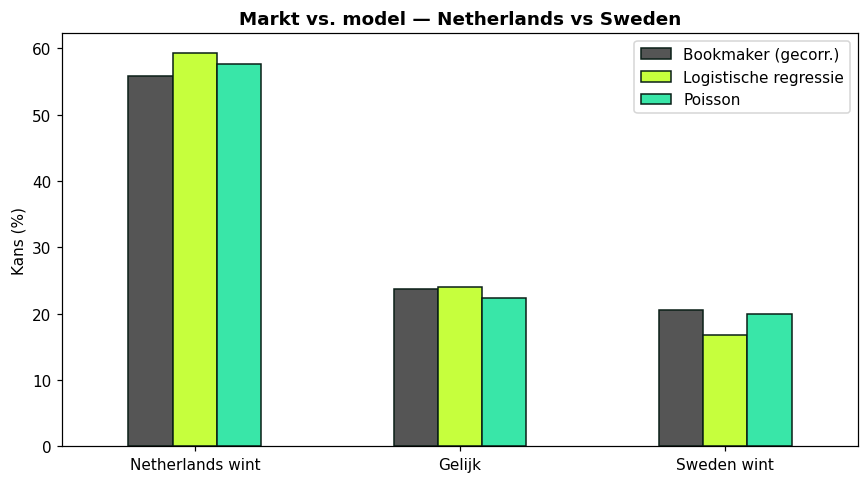

,Bookmaker (gecorr.),Logistische regressie,Poisson
Netherlands wint,55.700,59.300,57.600
Gelijk,23.700,24.000,22.400
Sweden wint,20.600,16.700,20.000


In [14]:
# Decimale odds — pas aan per wedstrijd (None = sla de vergelijking over)
ODDS = {"home": 1.72, "draw": 4.05, "away": 4.66}   # NL - Zweden, 20 jun 2026

def compare_to_market(pred, odds):
    raw = {k: 1/v for k, v in odds.items()}
    over = sum(raw.values())
    implied = {k: v/over for k, v in raw.items()}
    home, away = pred["home"], pred["away"]
    tbl = pd.DataFrame({
        "Bookmaker (gecorr.)": [implied["home"], implied["draw"], implied["away"]],
        "Logistische regressie": [pred["lr"]["home"], pred["lr"]["draw"], pred["lr"]["away"]],
        "Poisson": [pred["poisson"]["home"], pred["poisson"]["draw"], pred["poisson"]["away"]],
    }, index=[f"{home} wint", "Gelijk", f"{away} wint"])
    print(f"Overround (bookmaker-marge): {(over-1)*100:.1f}%")
    print(f"Model-edge op '{home} wint': "
          f"{pred['lr']['home'] - implied['home']:+.1%} (LR vs. markt)\n")
    ax = (tbl*100).plot(kind="bar", rot=0, figsize=(8, 4.5),
                        color=["#555", "#c6ff3d", "#39e6a8"], edgecolor="#0a1f17")
    ax.set_ylabel("Kans (%)"); ax.set_title(f"Markt vs. model — {home} vs {away}",
                                            fontweight="bold")
    plt.tight_layout(); plt.show()
    return (tbl*100).round(1)

if ODDS:
    display(compare_to_market(pred_nl_zwe, ODDS))

### Post-match: hoe goed was de voorspelling?

Eerlijke modelevaluatie scoort goed op LinkedIn. Draai dit **na afloop** met de echte uitkomst, dan vergelijken we de Brier-score van het model met die van de markt (lager = beter).

In [15]:
# Vul na de wedstrijd in: "home" (NL wint), "draw", of "away" (Zweden wint)
ACTUAL = None

def brier_report(pred, actual, odds=None):
    labels = ["home", "draw", "away"]
    y = np.array([1 if l == actual else 0 for l in labels])
    rows = [("Logistische regressie", [pred["lr"][l] for l in labels]),
            ("Poisson",               [pred["poisson"][l] for l in labels])]
    if odds:
        raw = {k: 1/v for k, v in odds.items()}; over = sum(raw.values())
        rows.append(("Markt", [raw[l]/over for l in labels]))
    for name, probs in rows:
        score = np.mean((np.array(probs) - y) ** 2)
        print(f"  {name:24s} Brier: {score:.3f}")

if ACTUAL:
    brier_report(pred_nl_zwe, ACTUAL, ODDS)
else:
    print("Vul ACTUAL in na de wedstrijd om de Brier-scores te berekenen.")

Vul ACTUAL in na de wedstrijd om de Brier-scores te berekenen.


## 7. De WK 2026-loting reconstrueren

De toekomstige wedstrijden in de dataset vormen de 12 groepen. Twee teams die elkaar in de groepsfase treffen, zitten in dezelfde groep - dus we bouwen een graaf en pakken de *connected components*. Dat geeft exact 12 groepen van 4.

In [16]:
import networkx as nx

wc = df[(df["tournament"] == "FIFA World Cup") & (df["date"] >= "2026-06-01")]
G = nx.Graph()
for r in wc.itertuples(index=False):
    G.add_edge(r.home_team, r.away_team)

groups_raw = [sorted(c) for c in nx.connected_components(G)]
groups_raw.sort(key=lambda g: -max(elo[t] for t in g))  # cosmetisch op sterkte
GROUPS = {name: teams for name, teams in zip("ABCDEFGHIJKL", groups_raw)}

for g, teams in GROUPS.items():
    print(f"Groep {g}: " + ", ".join(f"{t} ({elo[t]:.0f})" for t in
          sorted(teams, key=lambda x: -elo[x])))

Groep A: Argentina (2188), Austria (1913), Algeria (1856), Jordan (1736)
Groep B: Spain (2177), Uruguay (1938), Saudi Arabia (1713), Cape Verde (1684)
Groep C: France (2131), Norway (1991), Senegal (1879), Iraq (1711)
Groep D: England (2111), Croatia (1934), Panama (1781), Ghana (1677)
Groep E: Colombia (2066), Portugal (2014), Uzbekistan (1799), DR Congo (1774)
Groep F: Brazil (2056), Morocco (2011), Scotland (1841), Haiti (1656)
Groep G: Germany (2017), Ecuador (1964), Ivory Coast (1862), Curaçao (1585)
Groep H: Netherlands (2007), Japan (1992), Sweden (1824), Tunisia (1685)
Groep I: Mexico (1986), South Korea (1880), Czech Republic (1767), South Africa (1662)
Groep J: Switzerland (1951), Canada (1885), Bosnia and Herzegovina (1667), Qatar (1584)
Groep K: United States (1936), Australia (1904), Paraguay (1885), Turkey (1871)
Groep L: Belgium (1930), Iran (1876), Egypt (1814), New Zealand (1731)


### Live-status: wat is al gespeeld?

Tijdens het toernooi loopt de GitHub-data mee: gespeelde WK-wedstrijden krijgen een echte uitslag, de rest blijft `NaN`. We splitsen de groepswedstrijden daarom in **gespeeld** (uitslag staat vast) en **nog te spelen** (simuleren). Zo voorspelt het model niet langer wedstrijden die in werkelijkheid al gespeeld zijn - en wordt elke update een echt momentopname-verhaal: *de titelkansen na speelronde X*.

In [17]:
wc_played = wc.dropna(subset=["home_score", "away_score"]).copy()
wc_played["home_score"] = wc_played["home_score"].astype(int)
wc_played["away_score"] = wc_played["away_score"].astype(int)

# bekende uitslagen als lookup (beide richtingen afdekken)
KNOWN = {}
for r in wc_played.itertuples(index=False):
    KNOWN[(r.home_team, r.away_team)] = (r.home_score, r.away_score)

total_group_matches = sum(len(t) * (len(t) - 1) // 2 for t in GROUPS.values())
print(f"Groepswedstrijden gespeeld: {len(wc_played)} / {total_group_matches}")
print(f"Nog te simuleren: {total_group_matches - len(wc_played)}")
if len(wc_played):
    print("\nLaatste uitslagen:")
    for r in wc_played.sort_values("date").tail(6).itertuples(index=False):
        print(f"  {r.date.date()}  {r.home_team} {r.home_score}-{r.away_score} {r.away_team}")

Groepswedstrijden gespeeld: 32 / 72
Nog te simuleren: 40

Laatste uitslagen:
  2026-06-18  Switzerland 4-1 Bosnia and Herzegovina
  2026-06-18  Canada 6-0 Qatar
  2026-06-19  Scotland 0-1 Morocco
  2026-06-19  Turkey 0-1 Paraguay
  2026-06-19  United States 2-0 Australia
  2026-06-19  Brazil 3-0 Haiti


> **Reproduceerbaarheid.** Omdat de live data doorloopt, hoort bij elke LinkedIn-post een snapshot (hierboven opgeslagen met datum). Wil je een oude post exact reproduceren? Laad dan dat snapshot-bestand in plaats van de live URL. Het ML-model traint op de historie en verandert niet merkbaar; alleen de toernooistand schuift mee.

## 7b. Verwachte goals per deelnemend land

Ons Poisson-model geeft per duel een verwacht aantal goals. We kunnen dat aggregeren tot een profiel per land: hoeveel goals verwacht een team te **maken** (aanvalskracht) en te **incasseren** (defensieve kwetsbaarheid), gemiddeld over zijn drie echte groepswedstrijden.

Dit is realistischer dan een abstract gemiddelde, want het houdt rekening met de *werkelijke* loting: hetzelfde team in een zwakke groep ziet er sterker uit dan in een loodzware. Ter referentie zetten we er ook de xG tegen een **gemiddelde** WK-tegenstander naast.

In [18]:
# tegenstanders van elk land = de andere 3 in zijn groep
opponents = {t: [x for x in teams if x != t] for teams in GROUPS.values() for t in teams}
avg_elo = np.mean([elo[t] for t in opponents])

xg_rows = []
for t in opponents:
    xf = np.mean([expected_goals(elo[t], elo[o])[0] for o in opponents[t]])   # goals voor
    xa = np.mean([expected_goals(elo[o], elo[t])[0] for o in opponents[t]])   # goals tegen
    xf_neutral = MU * np.exp(BETA * (elo[t] - avg_elo) / 200)                 # vs gemiddeld land
    xg_rows.append({"team": t, "elo": round(elo[t]),
                    "xG_voor": round(xf, 2), "xG_tegen": round(xa, 2),
                    "xG_saldo": round(xf - xa, 2), "xG_vs_gemiddeld": round(xf_neutral, 2)})

xg_df = pd.DataFrame(xg_rows).sort_values("xG_saldo", ascending=False).reset_index(drop=True)
xg_df.head(15)

,team,elo,xG_voor,xG_tegen,xG_saldo,xG_vs_gemiddeld
0,Spain,2177,2.750,0.710,2.040,2.300
1,Argentina,2188,2.520,0.760,1.760,2.340
2,England,2111,2.370,0.820,1.560,2.050
3,France,2131,2.210,0.880,1.330,2.130
4,Switzerland,1951,2.100,0.930,1.170,1.560
5,Brazil,2056,2.050,0.970,1.080,1.870
6,Germany,2017,2.050,0.990,1.060,1.750
7,Mexico,1986,2.000,0.960,1.040,1.660
8,Colombia,2066,1.970,0.990,0.980,1.900
9,Netherlands,2007,1.880,1.040,0.840,1.720


Een scatter maakt het in één oogopslag duidelijk: aanvalskracht op de x-as, defensie (omgekeerd) op de y-as. **Rechtsboven** = veel maken én weinig incasseren: de favorieten. **Linksonder** = de outsiders.

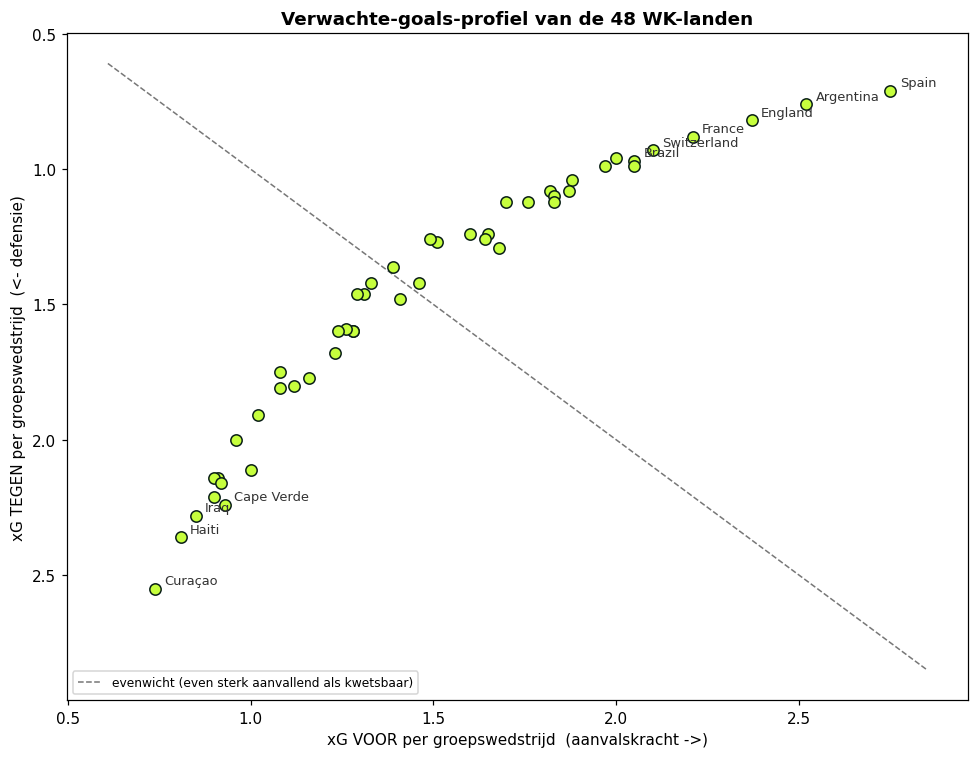

In [19]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(xg_df["xG_voor"], xg_df["xG_tegen"], s=55, color="#c6ff3d",
           edgecolor="#0a1f17", zorder=3)

# diagonaal: xG_voor == xG_tegen (evenwicht)
lim = [xg_df[["xG_voor","xG_tegen"]].min().min() - 0.1,
       xg_df[["xG_voor","xG_tegen"]].max().max() + 0.1]
ax.plot(lim, lim, "--", color="#777", lw=1, label="evenwicht (even sterk aanvallend als kwetsbaar)")

# label de uitersten
for _, r in pd.concat([xg_df.head(6), xg_df.tail(4)]).iterrows():
    ax.annotate(r["team"], (r["xG_voor"], r["xG_tegen"]),
                textcoords="offset points", xytext=(6, 3), fontsize=8.5, color="#333")

ax.set_xlabel("xG VOOR per groepswedstrijd  (aanvalskracht ->)")
ax.set_ylabel("xG TEGEN per groepswedstrijd  (<- defensie)")
ax.invert_yaxis()  # minder tegen = hoger = beter
ax.set_title("Verwachte-goals-profiel van de 48 WK-landen", fontweight="bold")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

De interpretatie sluit naadloos aan op de titelkansen verderop: de teams rechtsboven in deze plot zijn precies degene met de hoogste simulatie-uitkomsten. Het mooie is dat dit een *andere route* naar dezelfde conclusie is - de xG-profielen komen direct uit het Poisson-model, los van de Monte-Carlo-simulatie, en ze wijzen dezelfde kant op. Twee onafhankelijke checks die elkaar bevestigen.

## 8. Toernooi-simulatie

We combineren beide modellen, en we **conditioneren op wat al gebeurd is**:
- **Groepsfase** - al gespeelde wedstrijden tellen mee met hun *echte* uitslag; alleen de nog te spelen wedstrijden trekken we uit het Poisson-scorelinemodel (geeft punten *en* doelsaldo voor de ranglijst).
- **Knockout** - zelfde scorelinemodel, maar gelijkspel wordt beslist; bij een Poisson-gelijkspel wint het sterkste team naar rato (proxy voor verlenging/penalty's).

Regels WK 2026: 12 groepen van 4, top 2 + de **8 beste nummers 3** door naar de Ronde van 32, daarna knockout tot de finale.

In [20]:
def sim_scoreline(a, b, neutral=True):
    lh, la = expected_goals(elo[a], elo[b], neutral)
    return RNG.poisson(lh), RNG.poisson(la)

def sim_knockout(a, b):
    ga, gb = sim_scoreline(a, b)
    if ga > gb: return a
    if gb > ga: return b
    # 'verlenging/penalty's': sterkste team wint naar rato van Elo
    pa = 1.0 / (1.0 + 10 ** ((elo[b] - elo[a]) / 400.0))
    return a if RNG.random() < pa else b

def match_result(a, b):
    """Echte uitslag als die bekend is, anders een simulatie uit het Poisson-model."""
    if (a, b) in KNOWN:
        return KNOWN[(a, b)]
    if (b, a) in KNOWN:
        gb, ga = KNOWN[(b, a)]   # omgedraaid opgeslagen
        return ga, gb
    return sim_scoreline(a, b)

def play_group(teams):
    pts = {t: 0 for t in teams}; gd = {t: 0 for t in teams}; gf = {t: 0 for t in teams}
    for i in range(len(teams)):
        for j in range(i+1, len(teams)):
            a, b = teams[i], teams[j]
            ga, gb = match_result(a, b)   # vaste uitslag of simulatie
            gf[a]+=ga; gf[b]+=gb; gd[a]+=ga-gb; gd[b]+=gb-ga
            if ga>gb: pts[a]+=3
            elif gb>ga: pts[b]+=3
            else: pts[a]+=1; pts[b]+=1
    ranked = sorted(teams, key=lambda t: (pts[t], gd[t], gf[t], elo[t]), reverse=True)
    return ranked, pts, gd, gf

In [21]:
def run_tournament():
    winners, runners, thirds = {}, {}, []
    for g, teams in GROUPS.items():
        ranked, pts, gd, gf = play_group(teams)
        winners[g], runners[g] = ranked[0], ranked[1]
        thirds.append((ranked[2], pts[ranked[2]], gd[ranked[2]], gf[ranked[2]]))
    best_thirds = [t for t, *_ in sorted(thirds, key=lambda x: (x[1], x[2], x[3], elo[x[0]]),
                                         reverse=True)[:8]]
    qualified = list(winners.values()) + list(runners.values()) + best_thirds

    # VASTE bracket: na de loting ligt het schema vast. We schudden de 32 teams
    # eenmalig en spelen de boom daarna ongewijzigd af - geen herseeding per ronde.
    # Dit geeft elk team een eerlijke kans op een gunstig of ongunstig pad, precies
    # zoals in een echt toernooi. (Herseeden per ronde zou zwakke teams structureel
    # tegen de sterkste tegenstander zetten en hen dubbel straffen.)
    bracket = qualified[:]
    RNG.shuffle(bracket)

    def ko_round(teams):
        return [sim_knockout(teams[i], teams[i+1]) for i in range(0, len(teams), 2)]

    r16 = ko_round(bracket)     # 32 -> 16
    qf  = ko_round(r16)         # 16 -> 8
    sf  = ko_round(qf)          # 8  -> 4
    fin = ko_round(sf)          # 4  -> 2
    champ = ko_round(fin)[0]    # 2  -> 1
    # positie-info per groep voor de visualisaties:
    pos1 = set(winners.values()); pos2 = set(runners.values()); pos3in = set(best_thirds)
    return champ, set(fin), set(sf), set(qualified), pos1, pos2, pos3in

In [22]:
N = 50_000
champ_c, final_c, sf_c, qual_c = defaultdict(int), defaultdict(int), defaultdict(int), defaultdict(int)
p1_c, p2_c, p3_c = defaultdict(int), defaultdict(int), defaultdict(int)   # positiekansen

for _ in range(N):
    champ, finalists, semis, qualified, pos1, pos2, pos3in = run_tournament()
    champ_c[champ] += 1
    for t in finalists: final_c[t] += 1
    for t in semis: sf_c[t] += 1
    for t in qualified: qual_c[t] += 1
    for t in pos1: p1_c[t] += 1
    for t in pos2: p2_c[t] += 1
    for t in pos3in: p3_c[t] += 1

all_teams = sorted(set().union(*[set(v) for v in GROUPS.values()]))
pred = pd.DataFrame([{
    "team": t, "elo": round(elo[t], 1),
    "titel_%": 100*champ_c[t]/N, "finale_%": 100*final_c[t]/N,
    "halve_finale_%": 100*sf_c[t]/N, "knockout_%": 100*qual_c[t]/N,
    "p1_%": 100*p1_c[t]/N, "p2_%": 100*p2_c[t]/N, "p3in_%": 100*p3_c[t]/N,
} for t in all_teams]).sort_values("titel_%", ascending=False).reset_index(drop=True)

print(f"{N:,} gesimuleerde toernooien\n")
pred.head(15)

50,000 gesimuleerde toernooien



,team,elo,titel_%,finale_%,halve_finale_%,knockout_%,p1_%,p2_%,p3in_%
0,Argentina,"2,188.300",21.636,32.008,45.480,99.906,85.984,12.948,0.974
1,Spain,"2,177.300",18.796,28.698,41.688,96.338,70.466,20.010,5.862
2,France,"2,131.200",12.270,21.492,34.662,99.738,69.152,28.048,2.538
3,England,"2,110.800",9.902,18.404,31.132,99.818,92.980,5.748,1.090
4,Colombia,"2,065.700",6.070,12.582,23.826,98.648,70.368,22.192,6.088
5,Brazil,"2,056.100",5.262,11.432,22.206,100.000,59.702,24.220,16.078
6,Germany,"2,017.200",3.206,7.984,17.246,99.768,66.326,21.600,11.842
7,Morocco,"2,010.900",3.056,7.346,16.312,99.998,35.996,61.810,2.192
8,Netherlands,"2,006.600",2.470,6.554,14.618,92.346,39.588,35.486,17.272
9,Portugal,"2,014.200",2.382,5.980,13.116,79.770,22.808,43.464,13.498


## 9. De favorieten

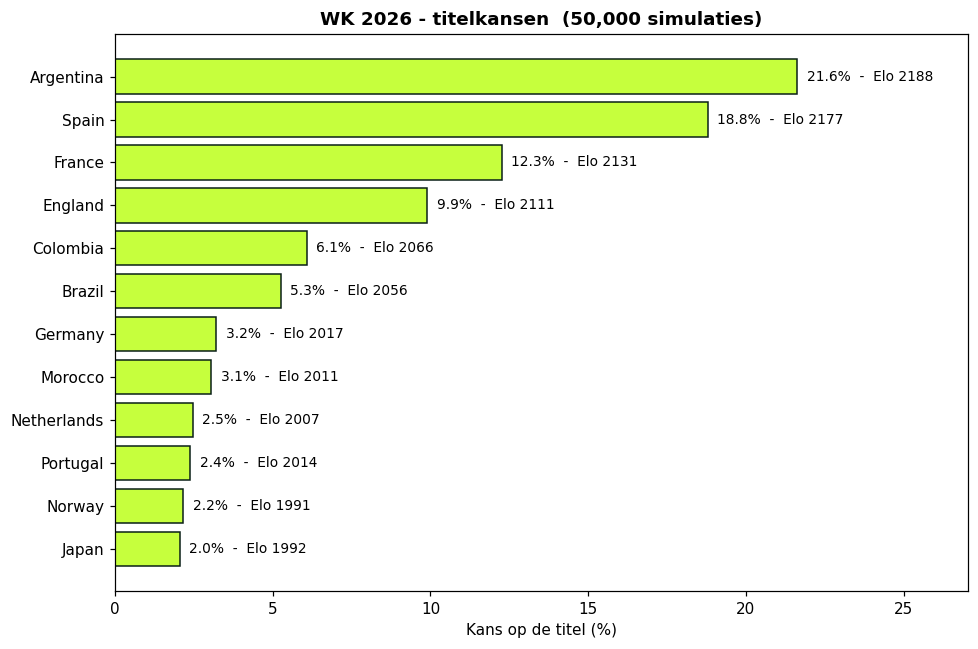

In [23]:
top = pred.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["team"], top["titel_%"], color="#c6ff3d", edgecolor="#0a1f17")
for y, (v, e) in enumerate(zip(top["titel_%"], top["elo"])):
    ax.text(v + 0.3, y, f"{v:.1f}%  -  Elo {e:.0f}", va="center", fontsize=9)
ax.set_xlabel("Kans op de titel (%)")
ax.set_title(f"WK 2026 - titelkansen  ({N:,} simulaties)", fontweight="bold")
ax.set_xlim(0, top["titel_%"].max() * 1.25)
plt.tight_layout(); plt.show()

## 10. Resultaten opslaan

In [24]:
pred.to_csv("wk2026_predictions.csv", index=False)
xg_df.to_csv("wk2026_expected_goals.csv", index=False)
pd.DataFrame([{"team": t, "elo": round(elo[t],1)} for t in all_teams]
            ).sort_values("elo", ascending=False).to_csv("wk2026_elo_ratings.csv", index=False)
print("Opgeslagen: wk2026_predictions.csv, wk2026_expected_goals.csv, wk2026_elo_ratings.csv")
pred

Opgeslagen: wk2026_predictions.csv, wk2026_expected_goals.csv, wk2026_elo_ratings.csv


,team,elo,titel_%,finale_%,halve_finale_%,knockout_%,p1_%,p2_%,p3in_%
0,Argentina,"2,188.300",21.636,32.008,45.480,99.906,85.984,12.948,0.974
1,Spain,"2,177.300",18.796,28.698,41.688,96.338,70.466,20.010,5.862
2,France,"2,131.200",12.270,21.492,34.662,99.738,69.152,28.048,2.538
3,England,"2,110.800",9.902,18.404,31.132,99.818,92.980,5.748,1.090
4,Colombia,"2,065.700",6.070,12.582,23.826,98.648,70.368,22.192,6.088
5,Brazil,"2,056.100",5.262,11.432,22.206,100.000,59.702,24.220,16.078
6,Germany,"2,017.200",3.206,7.984,17.246,99.768,66.326,21.600,11.842
7,Morocco,"2,010.900",3.056,7.346,16.312,99.998,35.996,61.810,2.192
8,Netherlands,"2,006.600",2.470,6.554,14.618,92.346,39.588,35.486,17.272
9,Portugal,"2,014.200",2.382,5.980,13.116,79.770,22.808,43.464,13.498


## 11. Visuals

Drie gedeelde visualisaties in huisstijl, klaar om te uploaden: de titelkansen, het groepen-overzicht met de huidige stand, en een heatmap van de kans per ronde. Ze worden elke run opnieuw gemaakt met de actuele cijfers - dus na elke speelronde heb je verse beelden.

In [25]:
import matplotlib.colors as mcolors
from matplotlib.patches import FancyBboxPatch

# --- huisstijl ---
PITCH="#0a1f17"; CARD="#0f261c"; NEON="#c6ff3d"; NEON2="#39e6a8"
CHALK="#eafaf1"; MUTE="#7fa892"; DIM="#4d7a64"; LINE="#1d4838"; GOLD="#ffd24a"
BRAND = {"figure.facecolor":PITCH,"axes.facecolor":PITCH,"savefig.facecolor":PITCH,
    "text.color":CHALK,"axes.edgecolor":LINE,"axes.labelcolor":CHALK,
    "xtick.color":MUTE,"ytick.color":CHALK,"font.family":"DejaVu Sans"}

# Nederlandse namen
NL = {"Spain":"Spanje","Argentina":"Argentinië","France":"Frankrijk","England":"Engeland",
 "Colombia":"Colombia","Brazil":"Brazilië","Germany":"Duitsland","Portugal":"Portugal",
 "Netherlands":"Nederland","Morocco":"Marokko","Japan":"Japan","Norway":"Noorwegen",
 "Croatia":"Kroatië","Mexico":"Mexico","Belgium":"België","Uruguay":"Uruguay",
 "Switzerland":"Zwitserland","Austria":"Oostenrijk","Turkey":"Turkije","Australia":"Australië",
 "Senegal":"Senegal","Sweden":"Zweden","Ivory Coast":"Ivoorkust","Scotland":"Schotland",
 "South Korea":"Zuid-Korea","Paraguay":"Paraguay","United States":"VS","Canada":"Canada",
 "Algeria":"Algerije","Iran":"Iran","Egypt":"Egypte","Czech Republic":"Tsjechië",
 "Uzbekistan":"Oezbekistan","Panama":"Panama","DR Congo":"DR Congo","Jordan":"Jordanië",
 "Bosnia and Herzegovina":"Bosnië","Cape Verde":"Kaapverdië","Saudi Arabia":"Saoedi-Arab",
 "Iraq":"Irak","Tunisia":"Tunesië","New Zealand":"Nieuw-Zeela","Ghana":"Ghana",
 "Haiti":"Haïti","South Africa":"Zuid-Afrika","Qatar":"Qatar","Curaçao":"Curaçao","Ecuador":"Ecuador"}
nm = lambda t: NL.get(t, t)

AUTHOR = "Amusu Okamoto   ·   WK 2026-voorspeller"
def _footer(fig):
    fig.text(0.5, 0.020, AUTHOR, ha="center", color=MUTE, fontsize=11)
    fig.text(0.5, 0.004, "model: zelfgebouwde Elo + ML-classifier + 50.000 Monte-Carlo-simulaties      "
             "data: martj42/international_results  ·  ratings gevalideerd vs eloratings.net",
             ha="center", color=DIM, fontsize=8)

# huidige groepsstand uit de al gespeelde wedstrijden (KNOWN)
standings = defaultdict(lambda: {"pts":0,"gf":0,"ga":0,"sp":0})
for (h, a), (hs, as_) in KNOWN.items():
    standings[h]["gf"]+=hs; standings[h]["ga"]+=as_; standings[h]["sp"]+=1
    standings[a]["gf"]+=as_; standings[a]["ga"]+=hs; standings[a]["sp"]+=1
    if hs>as_: standings[h]["pts"]+=3
    elif hs<as_: standings[a]["pts"]+=3
    else: standings[h]["pts"]+=1; standings[a]["pts"]+=1

P = pred.set_index("team")

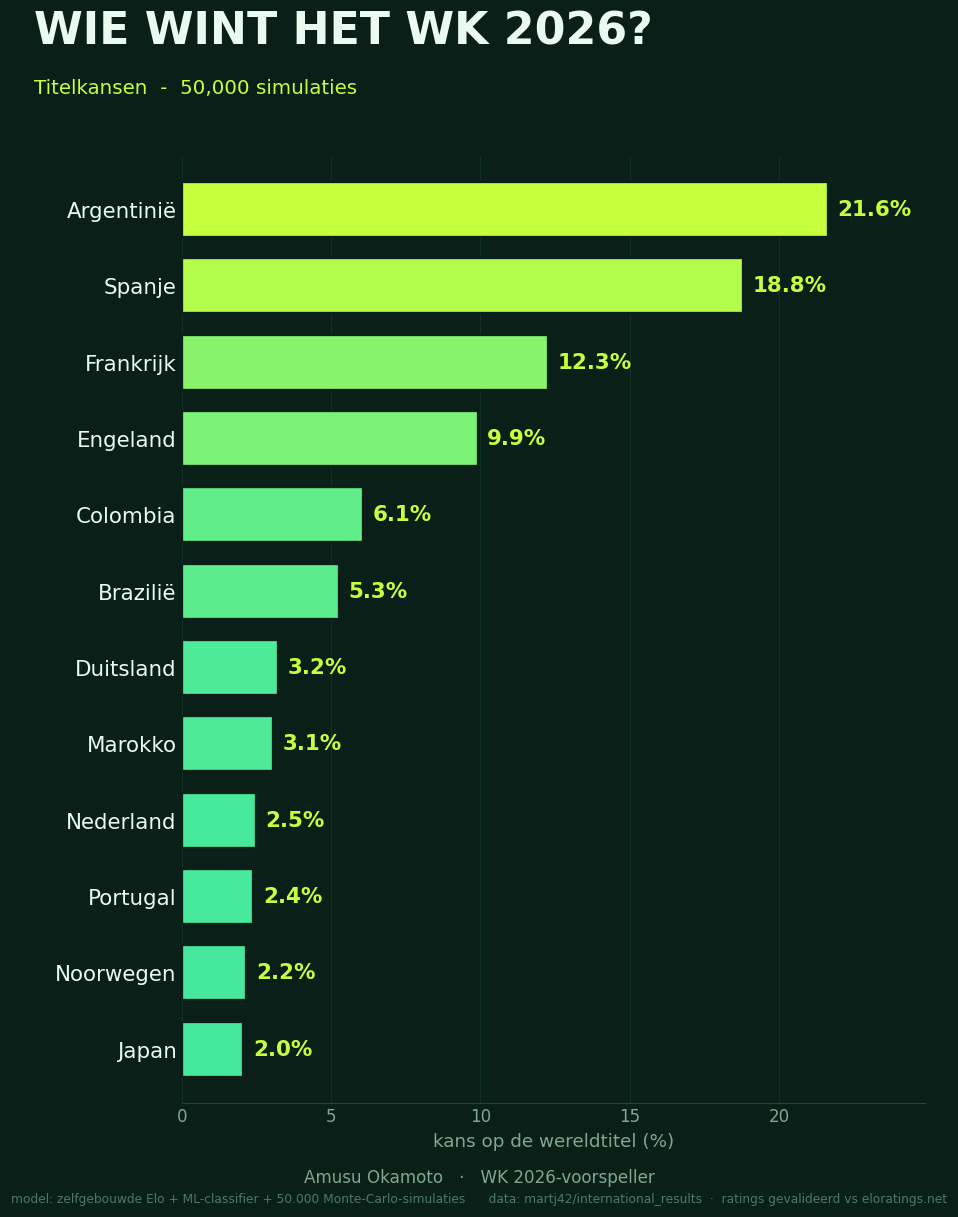

In [26]:
# ---------- 1. TITELKANSEN ----------
with plt.rc_context(BRAND):
    topn = pred.head(12).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 11.25))
    fig.subplots_adjust(left=0.20, right=0.95, top=0.85, bottom=0.085)
    cmap = mcolors.LinearSegmentedColormap.from_list("nz",[NEON2,NEON])
    vmax = topn["titel_%"].max()
    ax.barh(range(len(topn)), topn["titel_%"], color=[cmap(v/vmax) for v in topn["titel_%"]],
            edgecolor=PITCH, linewidth=1.5, zorder=3, height=0.72)
    for i,(_,r) in enumerate(topn.iterrows()):
        ax.text(r["titel_%"]+vmax*0.015, i, f'{r["titel_%"]:.1f}%', ha="left", va="center",
                fontsize=14, fontweight="bold", color=NEON)
    ax.set_xlim(0, vmax*1.15)
    ax.set_yticks(range(len(topn))); ax.set_yticklabels([nm(t) for t in topn["team"]], fontsize=14)
    ax.set_ylim(-0.7, len(topn)-0.3)
    for s in ["top","right","left"]: ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(LINE)
    ax.tick_params(axis="x", labelsize=11, length=0); ax.tick_params(axis="y", length=0)
    ax.set_xlabel("kans op de wereldtitel (%)", fontsize=12, color=MUTE)
    ax.xaxis.grid(True, color=LINE, lw=0.6, alpha=0.5, zorder=0); ax.set_axisbelow(True)
    fig.text(0.05, 0.94, "WIE WINT HET WK 2026?", fontsize=29, fontweight="bold", color=CHALK)
    fig.text(0.05, 0.90, f"Titelkansen  -  {N:,} simulaties", fontsize=13, color=NEON)
    _footer(fig)
    plt.savefig("post_1_titelkansen.png", dpi=200); plt.show()

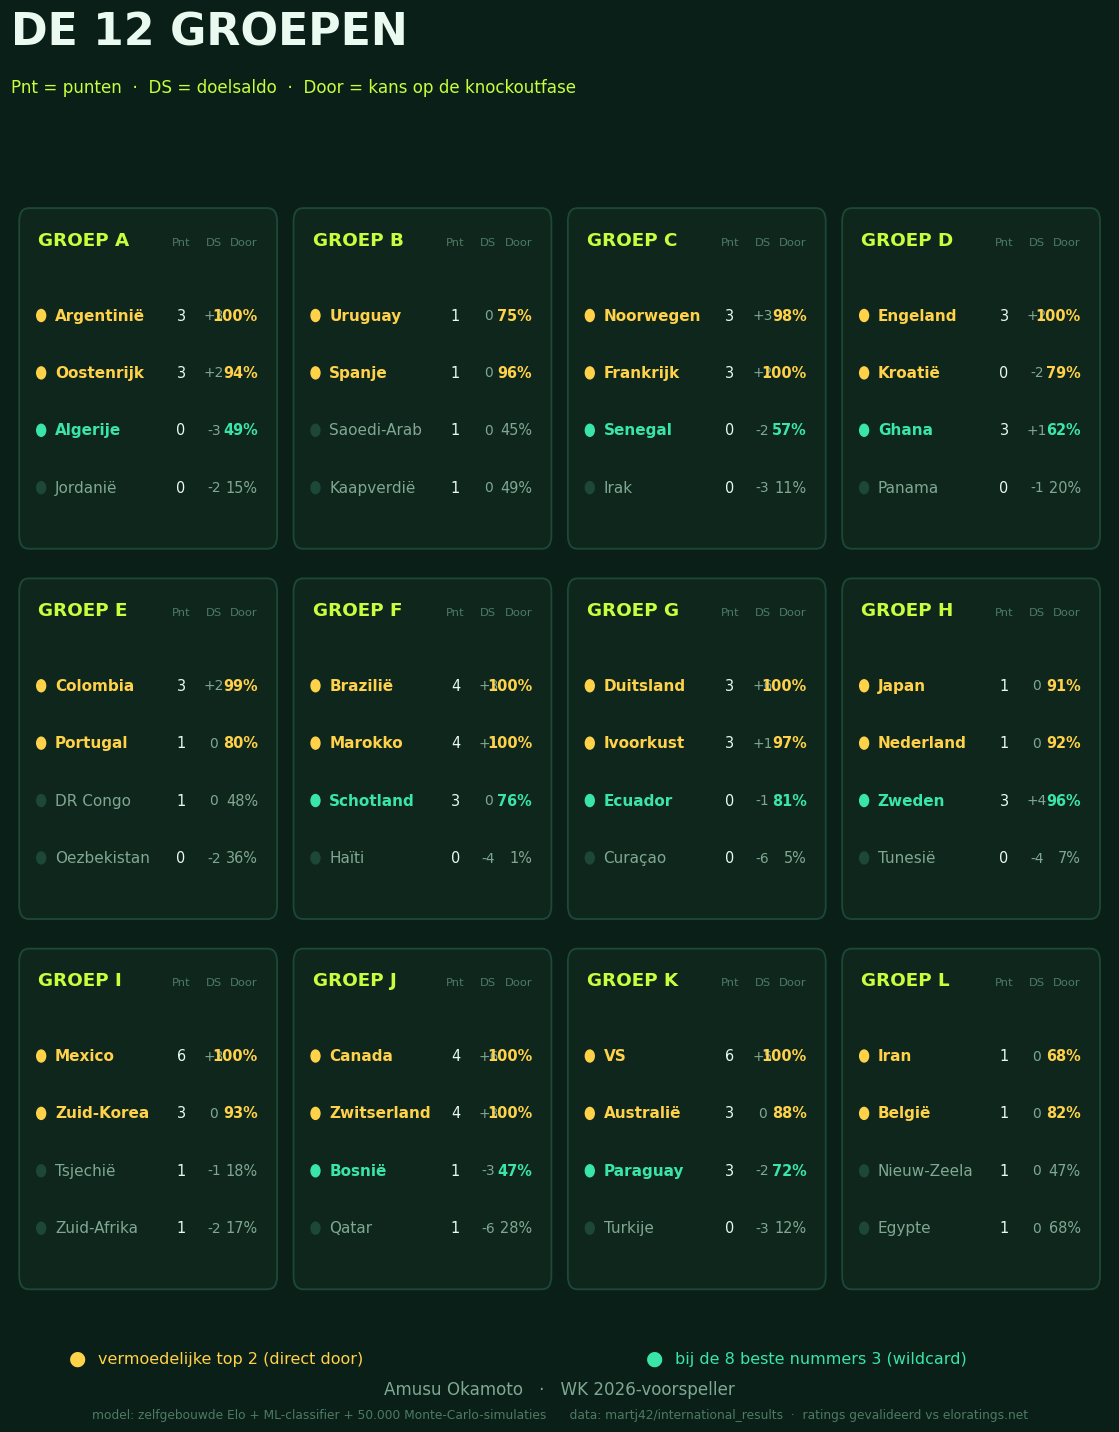

In [27]:
# ---------- 2. GROEPEN: goud boven, 8 beste nr 3 groen, grijs onder ----------
with plt.rc_context(BRAND):
    # vermoedelijke top 2 per groep (op p1+p2) en de 8 beste nummers 3 (op p3in)
    direct_by_group, third_cand = {}, []
    for g, teams in GROUPS.items():
        order = sorted(teams, key=lambda t: P.loc[t,"p1_%"]+P.loc[t,"p2_%"], reverse=True)
        direct_by_group[g] = set(order[:2])
        rest = [t for t in teams if t not in direct_by_group[g]]
        third = max(rest, key=lambda t: P.loc[t,"p3in_%"])
        third_cand.append((third, P.loc[third,"p3in_%"]))
    BEST8 = set(t for t,_ in sorted(third_cand, key=lambda x:-x[1])[:8])
    def _cat(g,t): return 0 if t in direct_by_group[g] else (1 if t in BEST8 else 2)

    fig, ax = plt.subplots(figsize=(10.5, 13.2))
    fig.subplots_adjust(left=0.025, right=0.975, top=0.85, bottom=0.085)
    ax.set_xlim(0,4); ax.set_ylim(0,3); ax.axis("off")
    for idx, g in enumerate(list("ABCDEFGHIJKL")):
        col=idx%4; row=idx//4; x0=col; y0=2-row
        rows=[]
        for t in GROUPS[g]:
            s=standings[t]; rows.append((t,_cat(g,t),s["pts"],s["gf"]-s["ga"],s["gf"],P.loc[t,"knockout_%"]))
        rows.sort(key=lambda r:(r[1], -r[2], -r[3], -r[4]))  # categorie, dan stand
        ax.add_patch(FancyBboxPatch((x0+0.04,y0+0.04),0.92,0.90,
                     boxstyle="round,pad=0.01,rounding_size=0.035",facecolor=CARD,edgecolor=LINE,lw=1.2,zorder=1))
        ax.text(x0+0.10,y0+0.85,f"GROEP {g}",fontsize=12,fontweight="bold",color=NEON,zorder=2)
        ax.text(x0+0.62,y0+0.85,"Pnt",fontsize=7.5,color=DIM,ha="center",zorder=2)
        ax.text(x0+0.74,y0+0.85,"DS",fontsize=7.5,color=DIM,ha="center",zorder=2)
        ax.text(x0+0.90,y0+0.85,"Door",fontsize=7.5,color=DIM,ha="right",zorder=2)
        for k,(t,c,pts,gd,gf,ko) in enumerate(rows):
            ty=y0+0.66-k*0.155
            if c==0: dot,ct,w=GOLD,GOLD,"bold"
            elif c==1: dot,ct,w=NEON2,NEON2,"bold"
            else: dot,ct,w=LINE,MUTE,"normal"
            ax.add_patch(plt.Circle((x0+0.11,ty),0.016,color=dot,zorder=3))
            ax.text(x0+0.16,ty,nm(t)[:11],fontsize=10,color=ct,zorder=2,fontweight=w,va="center")
            gds=f"+{int(gd)}" if gd>0 else f"{int(gd)}"
            ax.text(x0+0.62,ty,f"{int(pts)}",fontsize=9.5,color=CHALK,ha="center",va="center",zorder=2)
            ax.text(x0+0.74,ty,gds,fontsize=9,color=MUTE,ha="center",va="center",zorder=2)
            ax.text(x0+0.90,ty,f"{ko:.0f}%",fontsize=9.5,color=ct if c<2 else MUTE,ha="right",
                    va="center",zorder=2,fontweight="bold" if c<2 else "normal")
    fig.text(0.025,0.95,"DE 12 GROEPEN",fontsize=29,fontweight="bold",color=CHALK)
    fig.text(0.025,0.917,"Pnt = punten  ·  DS = doelsaldo  ·  Door = kans op de knockoutfase",fontsize=11,color=NEON)
    fig.text(0.075,0.045,"●",color=GOLD,fontsize=13,va="center")
    fig.text(0.10,0.045,"vermoedelijke top 2 (direct door)",fontsize=10.5,color=GOLD,va="center")
    fig.text(0.575,0.045,"●",color=NEON2,fontsize=13,va="center")
    fig.text(0.60,0.045,"bij de 8 beste nummers 3 (wildcard)",fontsize=10.5,color=NEON2,va="center")
    _footer(fig)
    plt.savefig("post_2_groepen.png", dpi=200); plt.show()

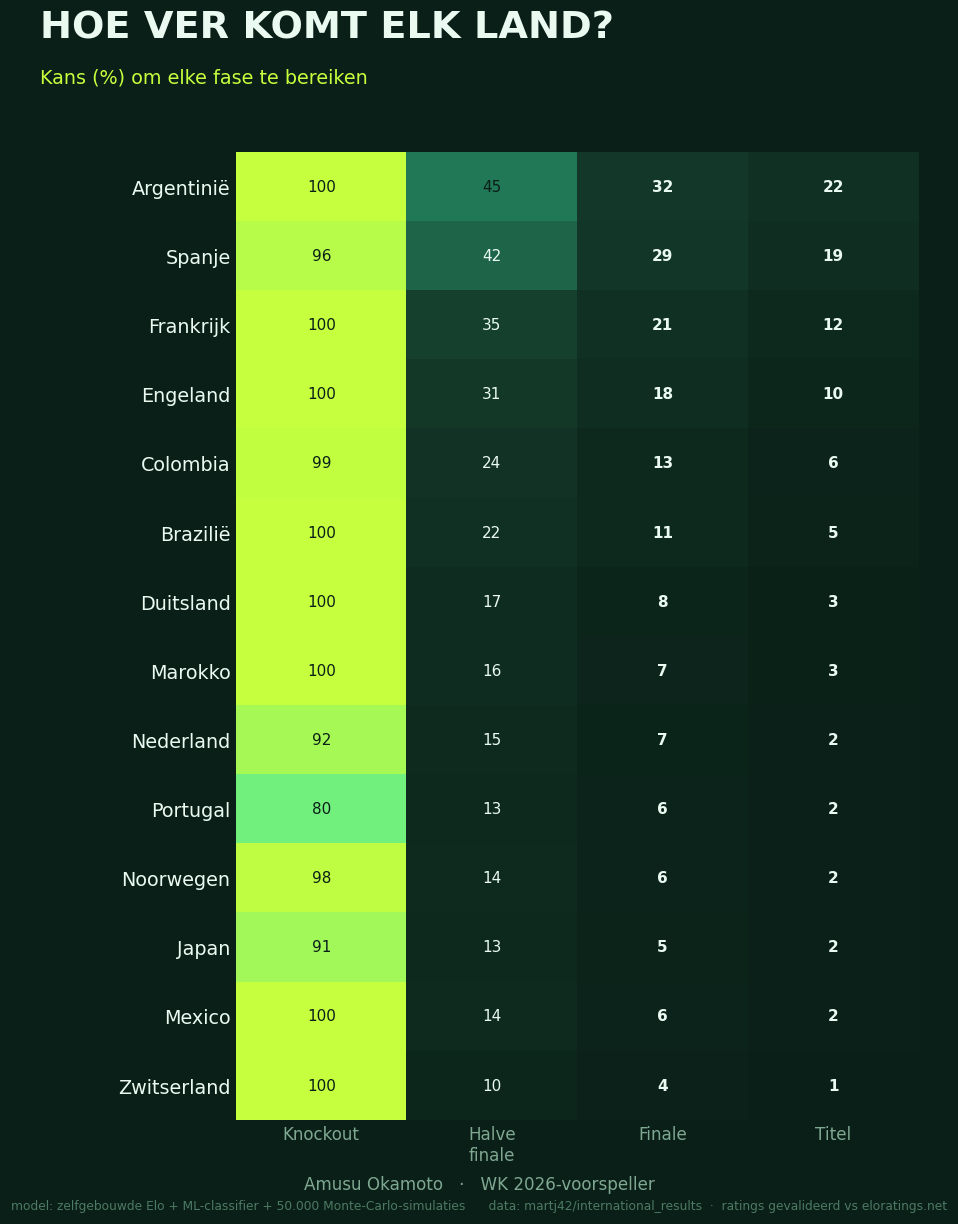

Opgeslagen: post_1_titelkansen.png, post_2_groepen.png, post_3_heatmap.png


In [28]:
# ---------- 3. HEATMAP: kans per ronde ----------
with plt.rc_context(BRAND):
    cols=["knockout_%","halve_finale_%","finale_%","titel_%"]
    labels=["Knockout","Halve\nfinale","Finale","Titel"]
    hm = pred.head(14).copy()
    M = hm[cols].values
    fig, ax = plt.subplots(figsize=(8.5, 11.5))
    fig.subplots_adjust(left=0.24, right=0.97, top=0.84, bottom=0.075)
    cmap = mcolors.LinearSegmentedColormap.from_list("hz",[PITCH,"#143a2a",NEON2,NEON])
    ax.imshow(M, aspect="auto", cmap=cmap, vmin=0, vmax=100)
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticks(range(len(hm))); ax.set_yticklabels([nm(t) for t in hm["team"]], fontsize=12.5)
    ax.tick_params(length=0)
    for i in range(len(hm)):
        for j in range(len(cols)):
            v=M[i,j]
            ax.text(j,i,f"{v:.0f}",ha="center",va="center",fontsize=10,
                    color=PITCH if v>45 else CHALK, fontweight="bold" if cols[j] in ("finale_%","titel_%") else "normal")
    for s in ax.spines.values(): s.set_visible(False)
    fig.text(0.03,0.93,"HOE VER KOMT ELK LAND?",fontsize=25,fontweight="bold",color=CHALK)
    fig.text(0.03,0.895,"Kans (%) om elke fase te bereiken",fontsize=12.5,color=NEON)
    _footer(fig)
    plt.savefig("post_3_heatmap.png", dpi=200); plt.show()
print("Opgeslagen: post_1_titelkansen.png, post_2_groepen.png, post_3_heatmap.png")

## 12. De wiskunde achter het model

Voor wie de formules wil zien — alle bouwstenen op een rij.

### Elo-rating

De verwachte score van team $A$ tegen team $B$ (een getal tussen 0 en 1), gegeven hun ratings $R_A$ en $R_B$:

$$E_A = \frac{1}{1 + 10^{\,(R_B - R_A)/400}}$$

Na de wedstrijd wordt de rating bijgewerkt met de werkelijke uitkomst $S_A \in \{1, \tfrac{1}{2}, 0\}$ (winst, gelijk, verlies):

$$R_A' = R_A + K \cdot G \cdot (S_A - E_A)$$

Hier is $K$ het toernooigewicht (een WK-duel weegt zwaarder dan een vriendschappelijke) en $G$ een **doelsaldo-multiplier** die grotere overwinningen sterker laat meetellen:

$$G = \begin{cases} 1 & |\Delta| \le 1 \\[4pt] \tfrac{3}{2} & |\Delta| = 2 \\[4pt] \dfrac{11 + |\Delta|}{8} & |\Delta| \ge 3 \end{cases}$$

met $\Delta$ het doelsaldo. Thuisspelende teams krijgen vooraf $+H$ Elo-punten opgeteld ($H = 65$), behalve op neutrale grond.

### Van Elo naar verwachte goals

Het verwachte aantal goals van elk team koppelen we log-lineair aan het Elo-verschil $d = R_A - R_B$, rond het toernooigemiddelde $\mu$:

$$\lambda_A = \mu \cdot e^{\,\beta d / 200}, \qquad \lambda_B = \mu \cdot e^{-\beta d / 200}$$

### Poisson-scorelines

Het aantal goals van elk team modelleren we als een Poisson-proces. De kans op precies $k$ goals:

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

De kans op een specifieke uitslag $(i, j)$ (onder aanname van onafhankelijkheid) is dan het product $P(X_A = i)\,P(X_B = j)$, en de kans op winst / gelijk / verlies volgt door over de juiste cellen van die matrix te sommeren.

### Ranked Probability Score (evaluatie)

Voor een geordende uitkomst (thuiswinst → gelijk → uitwinst) met voorspelde kansen $p_r$ en werkelijke uitkomst $o_r$:

$$\text{RPS} = \frac{1}{R-1} \sum_{i=1}^{R-1} \left( \sum_{r=1}^{i} p_r - \sum_{r=1}^{i} o_r \right)^2$$

met $R = 3$ uitkomstklassen. Lager is beter; de RPS straft voorspellingen die *qua ordening* ver van de waarheid zitten zwaarder dan een gewone kwadratische fout.

### Monte-Carlo-titelkans

De titelkans is simpelweg de frequentie waarmee een team kampioen wordt over $N$ gesimuleerde toernooien:

$$P(\text{kampioen} = T) \approx \frac{1}{N} \sum_{n=1}^{N} \mathbb{1}\{\text{winnaar}_n = T\}$$

De standaardfout van zo'n geschatte kans $\hat{p}$ schaalt met $\sqrt{\hat{p}(1-\hat{p})/N}$ — bij $N = 50\,000$ is die voor een kans rond 25% ongeveer $\pm 0{,}2$ procentpunt. Ruim nauwkeurig genoeg voor onze cijfers.


## 13. Conclusie & kanttekeningen

**Wat dit notebook laat zien**
- Een complete ML-pipeline: feature engineering -> getraind & geevalueerd classificatiemodel -> Poisson-scorelinemodel -> Monte-Carlo-toernooisimulatie.
- Eerlijke evaluatie met een temporele split, RPS en kalibratie tegen een baseline.
- De nuchtere bevinding dat het Elo-verschil het leeuwendeel van de voorspelkracht levert en de modelkeuze daarna weinig uitmaakt - een resultaat dat in de literatuur telkens terugkomt.

**Bewuste vereenvoudigingen (belangrijk voor je publiek)**
- De knockout-bracket wordt na de groepsfase eenmalig willekeurig geloot en daarna vast afgespeeld - net als een echt toernooi, waar de loting bepaalt wie elkaar wanneer treft. Het is niet de letterlijke officiele Ronde-van-32-structuur (die hangt af van welke acht nummers 3 doorgaan), maar het geeft elk team een eerlijke kans op een gunstig of ongunstig pad.
- Geen blessures, schorsingen, opstellingen of marktwaarden. Een logische volgende stap is bookmaker-odds of spelerratings als extra feature toevoegen.
- Een voorspelling is een **kansverdeling**, geen voorspelde uitslag. Dat een favoriet 25% titelkans heeft, betekent dat hij in 3 van de 4 simulaties juist *niet* wint. Daarom is voetbal leuk.
